# Preparación e Importación de Librerías

In [7]:
import pandas as pd #librería pandas para la manipulación y carga de datos.

from sklearn.model_selection import train_test_split #Función para dividir el dataset en conjuntos de entrenamiento y prueba.

from sklearn.svm import SVC #Clase principal para el clasificador de Máquina de Soporte Vectorial.

from sklearn.metrics import confusion_matrix, classification_report #Métricas de Scikit-learn para evaluar el rendimiento del modelo.

import seaborn as sns #Librerías para la visualización de datos y gráficos (especialmente la matriz de confusión).

import matplotlib.pyplot as plt
import numpy as np #Librería para operaciones numéricas y manipulación de arreglos.

file_path = r'C:\Users\57317\Documents\Universidad\Bootcam_IA\Data_ejemplo\Medicaldataset_2.csv'

df = pd.read_csv(file_path, sep=';')
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


# Carga y preparacion del dataset

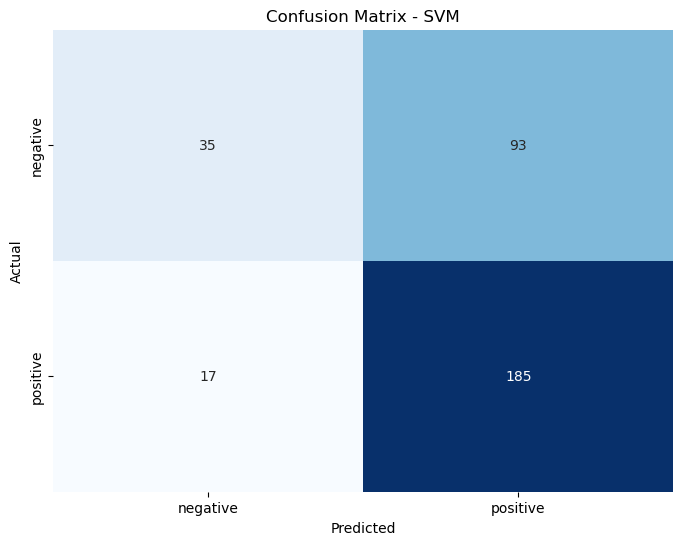

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.27      0.39       128
    positive       0.67      0.92      0.77       202

    accuracy                           0.67       330
   macro avg       0.67      0.59      0.58       330
weighted avg       0.67      0.67      0.62       330



In [ ]:
# Separar características (X) y variable objetivo (y)
X = df.drop('Result', axis=1)
y = df['Result']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Inicializar y entrenar el clasificador SVM (puedes ajustar el kernel)
svm = SVC(kernel='rbf', C=1, gamma='scale')  # También puedes usar 'linear' o 'poly'
svm.fit(X_train, y_train)

# Predecir sobre el conjunto de prueba
y_pred = svm.predict(X_test)

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

# Reporte de métricas de evaluación
#Genera el reporte de clasificación como un diccionario para facilitar la extracción de métricas.
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)


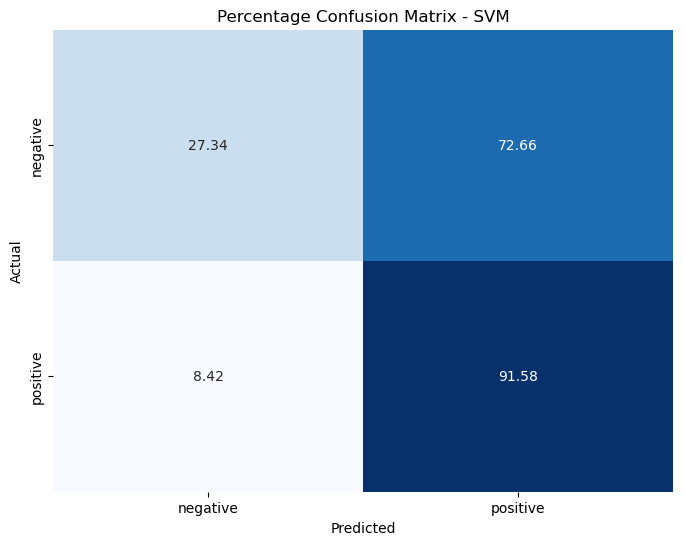

In [ ]:

# Calcular la matriz de confusión en porcentaje
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Graficar la matriz de confusión en porcentaje
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Percentage Confusion Matrix - SVM')
plt.show()


# Experimentacion con diferentes kernels

In [ ]:
#Define la lista de kernels a probar. Los tres son opciones comunes en sklearn.svm.SVC.
kernels = ['linear', 'poly', 'rbf']
macro_avg_f1_scores = {}

#Inicia un ciclo para entrenar un nuevo modelo para cada tipo de kernel en la lista.
for kernel_type in kernels:
    print(f"Training SVM with kernel: {kernel_type}")
    #"Inicializa el modelo usando el kernel_type de la iteración actual (lineal, polinomial o RBF)."
    svm = SVC(kernel=kernel_type, C=1, gamma='scale')
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)

    # Reporte de métricas de evaluación
    macro_avg_f1 = report['macro avg']['f1-score']
    #Extracción de Métrica Clave. Se extrae la métrica ""Macro Avg F1-score"" (Puntuación F1 de la media macro). Esta métrica es crucial porque calcula la Puntuación F1 para cada clase y luego toma el promedio simple, tratando a todas las clases por igual. Esto es importante para evaluar el rendimiento cuando las clases tienen tamaños desequilibrados."
    #Almacena el resultado F1 para cada kernel para su comparación final.    
    macro_avg_f1_scores[kernel_type] = macro_avg_f1
    print(f"Macro Avg F1-score for {kernel_type} kernel: {macro_avg_f1}\n")

print("Macro Avg F1-scores for different kernels:")
for kernel, f1 in macro_avg_f1_scores.items():
    print(f"{kernel}: {f1}")

Training SVM with kernel: linear
Macro Avg F1-score for linear kernel: 0.779520697167756

Training SVM with kernel: poly
Macro Avg F1-score for poly kernel: 0.6568212275529348

Training SVM with kernel: rbf
Macro Avg F1-score for rbf kernel: 0.5798611111111112

Macro Avg F1-scores for different kernels:
linear: 0.779520697167756
poly: 0.6568212275529348
rbf: 0.5798611111111112
